In [1]:
from google.colab import files
uploaded = files.upload()

Saving loan_data.csv to loan_data.csv


In [ ]:
import zipfile

with zipfile.ZipFile('archive.zip', 'r') as zip_ref:
    zip_ref.extractall()

In [ ]:
!ls

'archive (1).zip'  'archive (3).zip'   loan_data.csv
'archive (2).zip'   archive.zip        sample_data


In [ ]:
import pandas as pd

df = pd.read_csv('loan_data.csv')
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

In [ ]:
df.shape

(45000, 14)

**DATA CLEANING**

In [ ]:
df.isnull().sum()

,0
person_age,0
person_gender,0
person_education,0
person_income,0
person_emp_exp,0
person_home_ownership,0
loan_amnt,0
loan_intent,0
loan_int_rate,0
loan_percent_income,0


NO MISSING VALUES.

**DATA VISUALIZATION:**

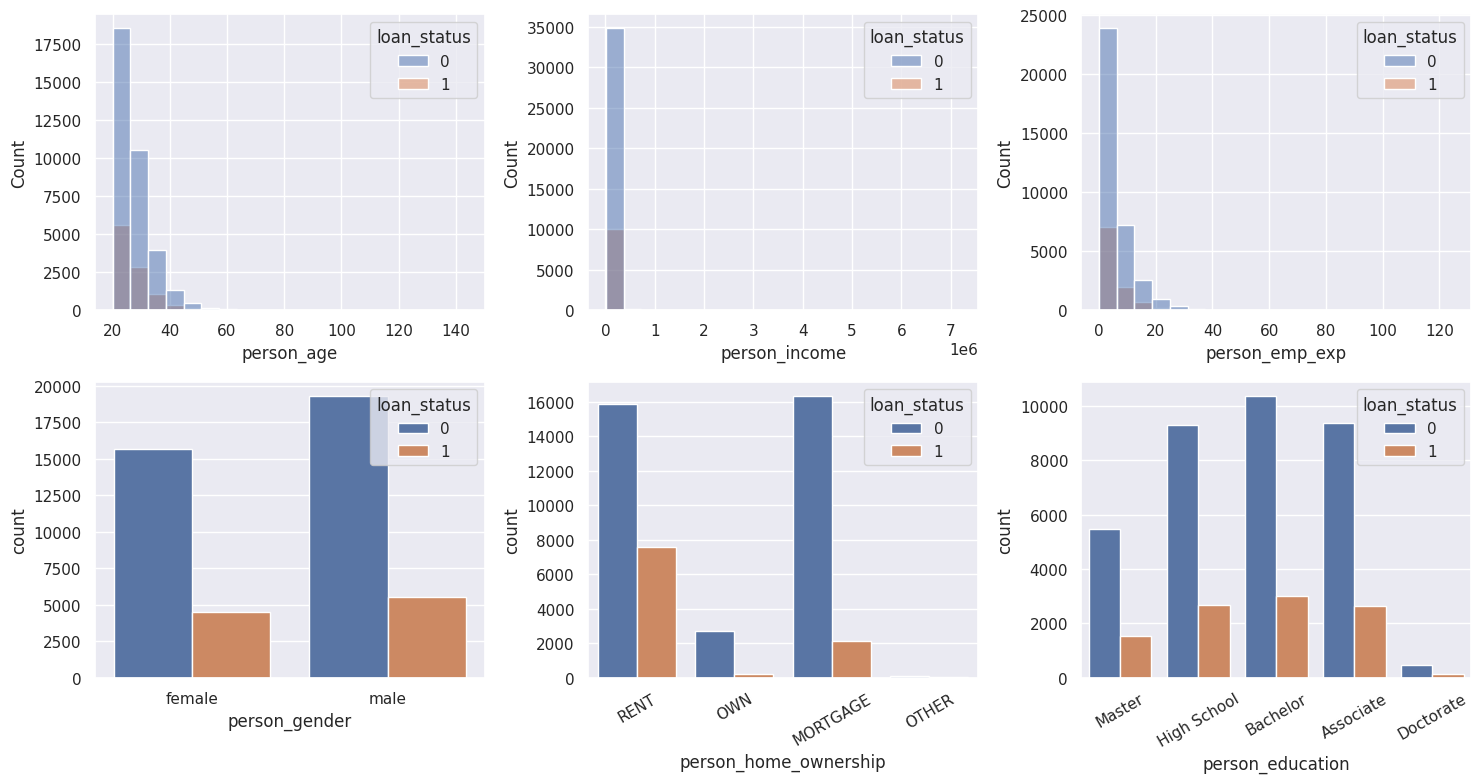

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15,8))
sns.set(font_scale=1)

plt.subplot(231)
sns.histplot(data=df, x='person_age', hue='loan_status', bins=20)

plt.subplot(232)
sns.histplot(data=df, x='person_income', hue='loan_status', bins=20)

plt.subplot(233)
sns.histplot(data=df, x='person_emp_exp', hue='loan_status', bins=20)

plt.subplot(234)
sns.countplot(x='person_gender', hue='loan_status', data=df)

plt.subplot(235)
sns.countplot(x='person_home_ownership', hue='loan_status', data=df)
plt.xticks(rotation=30)

plt.subplot(236)
sns.countplot(x='person_education', hue='loan_status', data=df)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## **LOGISTIC REGRESSION**
CATEGORICAl TO NUMERIC:

In [ ]:
df = pd.read_csv('/content/loan_data.csv')
categorical_cols = [
    'person_gender',
    'person_education',
    'person_home_ownership',
    'loan_intent',
    'previous_loan_defaults_on_file'
]
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
print(df.head())

   person_age  person_income  person_emp_exp  loan_amnt  loan_int_rate  \
0        22.0        71948.0               0    35000.0          16.02   
1        21.0        12282.0               0     1000.0          11.14   
2        25.0        12438.0               3     5500.0          12.87   
3        23.0        79753.0               0    35000.0          15.23   
4        24.0        66135.0               1    35000.0          14.27   

   loan_percent_income  cb_person_cred_hist_length  credit_score  loan_status  \
0                 0.49                         3.0           561            1   
1                 0.08                         2.0           504            0   
2                 0.44                         3.0           635            1   
3                 0.44                         2.0           675            1   
4                 0.53                         4.0           586            1   

   person_gender_male  ...  person_education_Master  \
0            

In [ ]:
X = df.drop('loan_status', axis=1)
y = df['loan_status']

In [ ]:
df = df.astype(int)

In [ ]:
df.head()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status,person_gender_male,...,person_education_Master,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,previous_loan_defaults_on_file_Yes
0,22,71948,0,35000,16,0,3,561,1,0,...,1,0,0,1,0,0,0,1,0,0
1,21,12282,0,1000,11,0,2,504,0,0,...,0,0,1,0,1,0,0,0,0,1
2,25,12438,3,5500,12,0,3,635,1,0,...,0,0,0,0,0,0,1,0,0,0
3,23,79753,0,35000,15,0,2,675,1,0,...,0,0,0,1,0,0,1,0,0,0
4,24,66135,1,35000,14,0,4,586,1,1,...,1,0,0,1,0,0,1,0,0,0


MODELING STAGE

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=0)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
predictions = model.predict(X_test)
print("Logistic Regression Accuracy:",accuracy_score(y_test, predictions))

Logistic Regression Accuracy: 0.8926666666666667


In [ ]:
X = df.drop('loan_status', axis=1)
y = df['loan_status']
import pandas as pd

importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

print(importance.sort_values(by='Coefficient', ascending=False))

                               Feature  Coefficient
5                  loan_percent_income     1.419692
4                        loan_int_rate     1.000437
15          person_home_ownership_RENT     0.339453
0                           person_age     0.129218
1                        person_income     0.049274
11        person_education_High School     0.038170
8                   person_gender_male     0.026017
12             person_education_Master     0.015143
13         person_home_ownership_OTHER     0.011780
9            person_education_Bachelor     0.000632
10          person_education_Doctorate    -0.001729
17         loan_intent_HOMEIMPROVEMENT    -0.013196
6           cb_person_cred_hist_length    -0.023966
2                       person_emp_exp    -0.104620
18                 loan_intent_MEDICAL    -0.118844
19                loan_intent_PERSONAL    -0.262340
16               loan_intent_EDUCATION    -0.355529
14           person_home_ownership_OWN    -0.393139
7           

PREDICTION vs ACTUAL

In [ ]:
print("predicted:", predictions)
print("actual",y_test.values)

predicted: [1 0 0 ... 0 0 0]
actual [1 0 0 ... 0 0 0]


**FINDINGS:**
* The model acheived an accuracy of approximately 89%, indicating good performance on the given dataset.


* Feature importance analysis shows that loan_percent_income and loan_int_rate are the most influential factors in predicting loan status.










*   The comparison between predicted and actual values shows that the model is making reliable predictions.

*  Overall, Logistic Regression proved to be an effective and simple algorithm for this binary classification problem.



